In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Get the current working directory
current_directory = os.getcwd()
# If required go to repository root
if os.path.split(current_directory)[1] != 'PAM_Parametrization':
    # Go up two levels
    parent_directory = os.path.dirname(os.path.dirname(current_directory))
    # Change the directory to the parent directory
    os.chdir(parent_directory)
    
from Scripts.i2_parametrization.pam_parametrizer_performance_analysis import get_statistics_from_df

Loading PAModelpy modules version 0.0.4.2
Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-06


## Get the model diagnostics 

In [2]:
DIAGNOSTIC_FILES = [os.path.join('Results','2_parametrization', 'diagnostics',
                                 f'pam_parametrizer_diagnostics_{file_nmbr}_1.xlsx')for file_nmbr in range(1,7)]

In [3]:
best_individual_df = None

for i, file in enumerate(DIAGNOSTIC_FILES):
    pam_param_results = pd.read_excel(file, sheet_name = 'Best_Individuals')
    pam_param_error = pd.read_excel(file, sheet_name='Final_Errors')
    pam_param_results = pam_param_results.merge(pam_param_error, on='run_id', how='left')
    pam_param_results['alternative'] = i+1
    
    if best_individual_df is None: 
        best_individual_df = pam_param_results
    else:
        best_individual_df = pd.concat([best_individual_df,pam_param_results])
best_individual_df

,run_id,enzyme_id,direction,rxn_id,kcat[s-1],ga_error,r_squared,alternative
0,1,P09053,f,CE_VPAMTr_P09053,0.967411,0.743487,0.425638,1
1,1,P09053,b,CE_VPAMTr_P09053,11.313011,0.743487,0.425638,1
2,1,P0A6P9,f,CE_ENO_P0A6P9,251.794281,0.743487,0.425638,1
3,1,P0A6P9,b,CE_ENO_P0A6P9,99.428596,0.743487,0.425638,1
4,1,P0A825,f,CE_GHMT2r_P0A825,65.228575,0.743487,0.425638,1
...,...,...,...,...,...,...,...,...
76963,10,Q6BF16,f,CE_DDPGALA_Q6BF16,144.931261,0.767474,0.317858,6
76964,10,Q6BF16,b,CE_DDPGALA_Q6BF16,6.688441,0.767474,0.317858,6
76965,10,Q6BF17,f,CE_GALCTND_Q6BF17,153.320973,0.767474,0.317858,6
76966,10,Q6BF17,b,CE_GALCTND_Q6BF17,45.264540,0.767474,0.317858,6


In [4]:
error_per_runid_config = get_statistics_from_df(best_individual_df,
                                                            group_by = ['run_id'],
                                                            columns = ['ga_error', 'r_squared'])
error_per_runid_config

,run_id,ga_error_mean,ga_error_median,ga_error_std,ga_error_min,ga_error_max,r_squared_mean,r_squared_median,r_squared_std,r_squared_min,r_squared_max
0,1,0.747402,0.747944,0.035649,0.680151,0.816482,0.280864,0.278418,0.111682,0.127462,0.426440
1,2,0.794894,0.767481,0.036202,0.718757,0.842109,0.401808,0.402089,0.115882,0.246422,0.564641
2,3,0.788849,0.773357,0.031480,0.719224,0.849166,0.381493,0.371624,0.120506,0.225224,0.585124
3,4,0.793705,0.783968,0.030269,0.720539,0.850689,0.393467,0.391410,0.111819,0.247757,0.578693
4,5,0.790519,0.784574,0.029425,0.741708,0.858618,0.412934,0.404970,0.099619,0.307650,0.592152
5,6,0.800394,0.797181,0.027196,0.743110,0.858618,0.417721,0.398250,0.104150,0.295401,0.592152
6,7,0.806273,0.800293,0.025660,0.750021,0.862831,0.406554,0.398639,0.135035,0.228397,0.605712
7,8,0.809369,0.803162,0.024333,0.760326,0.863844,0.437614,0.415761,0.108591,0.304777,0.610059
8,9,0.812836,0.810063,0.023325,0.766637,0.864256,0.443679,0.427994,0.101980,0.319948,0.608577
9,10,0.811347,0.802032,0.024133,0.767474,0.864897,0.432313,0.423586,0.097518,0.317858,0.604048


## Plot distribution

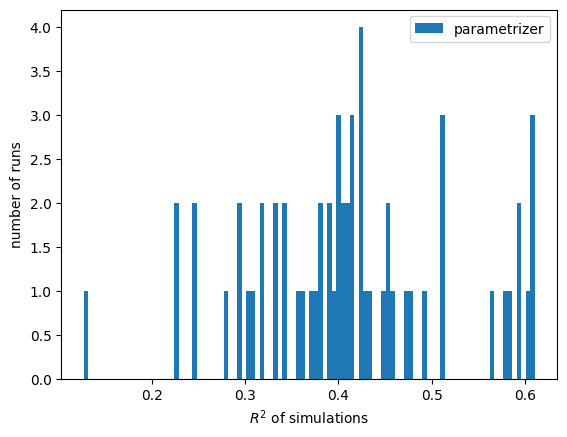

In [5]:
#plot histogram
bins =100

plt.hist(best_individual_df.drop_duplicates(['alternative', 'run_id']).r_squared, 
         bins= bins, label = 'parametrizer')
plt.xlabel('$R^{2}$ of simulations')
plt.ylabel('number of runs')
plt.legend()


## Plot evaluation of error during runs

## PAMparametrizer errors

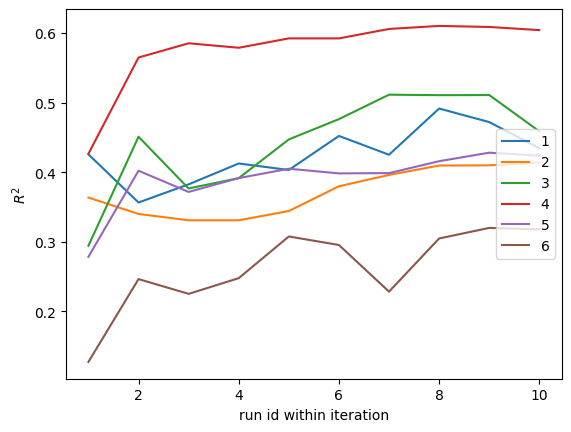

In [6]:
iteration = best_individual_df.drop(
    [col for col in best_individual_df.columns if col not in ['alternative', 'run_id', 'r_squared']], 
    axis=1).drop_duplicates(['alternative', 'run_id'], keep ='first').groupby('alternative')
fig, ax = plt.subplots()
for name, group in iteration:
    ax.plot(group['run_id'], group['r_squared'], label=name)
ax.set_xlabel('run id within iteration')
ax.set_ylabel('$R^{2}$')
plt.legend(loc = 'right')
plt.show()

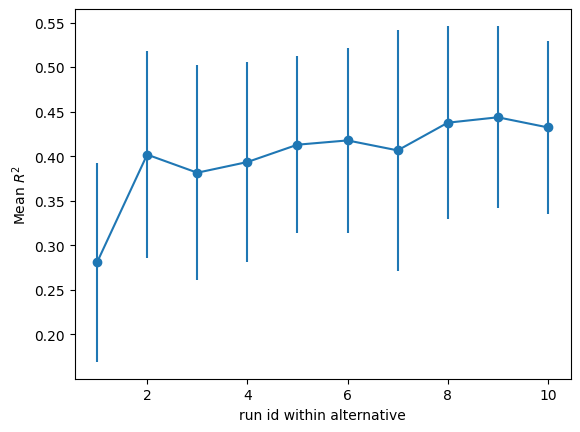

In [7]:
fig, ax = plt.subplots()
ax.scatter(error_per_runid_config['run_id'], error_per_runid_config['r_squared_mean'])
ax.errorbar(error_per_runid_config['run_id'], error_per_runid_config['r_squared_mean'],
            yerr = error_per_runid_config['r_squared_std'])
ax.set_xlabel('run id within alternative')
ax.set_ylabel('Mean $R^{2}$')
plt.show()

## Genetic Algorithm errors

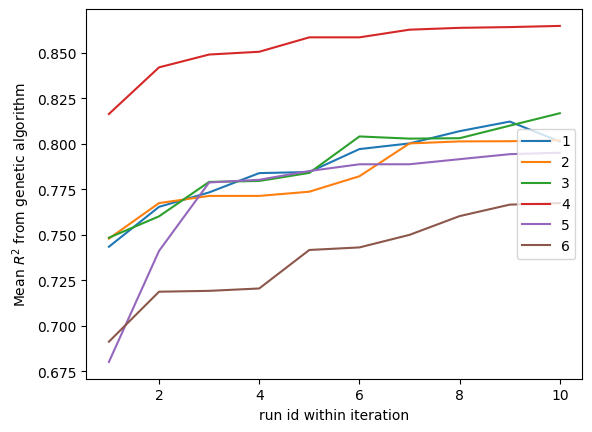

In [8]:
iteration = best_individual_df.drop(
    [col for col in best_individual_df.columns if col not in ['alternative', 'run_id', 'ga_error']], 
    axis=1).drop_duplicates(['alternative', 'run_id'], keep ='last').groupby('alternative')
fig, ax = plt.subplots()
for name, group in iteration:
    ax.plot(group['run_id'], group['ga_error'], label=name)
ax.set_xlabel('run id within iteration')
ax.set_ylabel('Mean $R^{2}$ from genetic algorithm')
plt.legend(loc = 'right')
plt.show()

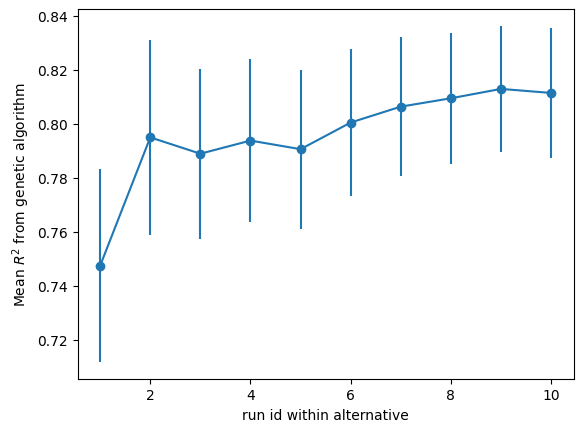

In [9]:
fig, ax = plt.subplots()
ax.scatter(error_per_runid_config['run_id'], error_per_runid_config['ga_error_mean'])
ax.errorbar(error_per_runid_config['run_id'], error_per_runid_config['ga_error_mean'],
            yerr = error_per_runid_config['ga_error_std'])
ax.set_xlabel('run id within alternative')
ax.set_ylabel('Mean $R^{2}$ from genetic algorithm')
plt.show()